# 04 · RubyHack: the RubyGems package campaign

**Question.** What can we say about the RubyGems campaign from the public report alone? Specifically: when the uploads happened, what the listed package names reveal about intent and self-identification, and whether the agents' own embedded timestamps agree with the registry's timeline.

**Inputs.**
- `data/processed/events_rubyhack.parquet` (one `package_published` event per gem named in the report)
- `data/interim/rubyhack/{gems,uploads_per_day}.parquet`

**Outputs.** Figures in `reports/figures/04_*.svg`, plus the Findings cell at the end.

**Caveats.**
- There is **no row-level package dataset**. The 286 names are the ones the report chose to show, out of 2,552 new names the registry saw. Proportions describe the *published sample*, not the campaign.
- Per-package upload times aren't published. Only names that embed a unix timestamp get a time, and that time is what the agent wrote, not the registry's.
- Registry enrichment (yanked versions, authors, created_at) is plan Stage 10.

In [1]:
from datetime import UTC, datetime

import altair as alt
import polars as pl

from agent_swarm import viz
from agent_swarm.paths import INTERIM_DIR, PROCESSED_DIR

alt.renderers.enable("svg")
alt.data_transformers.disable_max_rows()
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_hide_dataframe_shape(True)

ev = pl.read_parquet(PROCESSED_DIR / "events_rubyhack.parquet")
gems = pl.read_parquet(INTERIM_DIR / "rubyhack" / "gems.parquet")
uploads = pl.read_parquet(INTERIM_DIR / "rubyhack" / "uploads_per_day.parquet")
print(
    f"{ev.height} named gems · {gems['name_ts'].is_not_null().sum()} with an embedded unix timestamp · {uploads['total_uploads'].sum():,} registry uploads"
)

286 named gems · 10 with an embedded unix timestamp · 2,654 registry uploads


## 1 · When: registry uploads per day

These are the publisher's registry-derived daily counts. The chart shows totals on a symlog axis, and the table splits them into first uploads of new names and subsequent versions. Stacking isn't used, because it would distort proportions on a log scale. The shaded band is when RubyGems closed new registrations (May 12 08:54 → May 16 05:12 UTC, per the report).

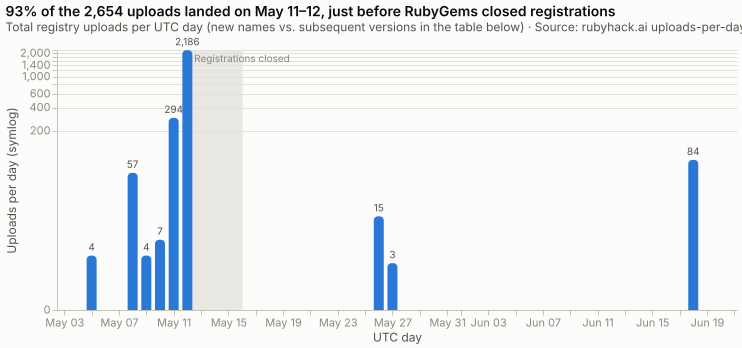

In [2]:
daily = (
    uploads.unpivot(
        index="date_utc",
        on=["new_package_names", "subsequent_versions"],
        variable_name="kind",
        value_name="uploads",
    )
    .with_columns(
        pl.col("kind").replace_strict(
            {"new_package_names": "New package names", "subsequent_versions": "Subsequent versions"}
        )
    )
    .filter(pl.col("uploads") > 0)
)
kind_order = ["New package names", "Subsequent versions"]
closed = pl.DataFrame(
    {
        "start": [datetime(2026, 5, 12, 8, 54, tzinfo=UTC)],
        "end": [datetime(2026, 5, 16, 5, 12, tzinfo=UTC)],
        "label": ["Registrations closed"],
    }
)
burst = uploads.filter(
    pl.col("date_utc").is_in([datetime(2026, 5, 11).date(), datetime(2026, 5, 12).date()])
)["total_uploads"].sum()
burst_share = burst / uploads["total_uploads"].sum()

band = alt.Chart(closed).mark_rect(color=viz.GRID, opacity=0.7).encode(x="start:T", x2="end:T")
band_label = (
    alt.Chart(closed)
    .mark_text(align="left", baseline="top", dx=4, dy=4, color=viz.INK_MUTED, fontSize=10)
    .encode(x="start:T", y=alt.value(0), text="label:N")
)
bars = (
    alt.Chart(uploads.filter(pl.col("total_uploads") > 0))
    .mark_bar(width=10, strokeWidth=0)
    .encode(
        x=alt.X(
            "date_utc:T",
            title="UTC day",
            axis=alt.Axis(format="%b %d"),
            scale=alt.Scale(domain=["2026-05-03", "2026-06-21"]),
        ),
        y=alt.Y(
            "total_uploads:Q", title="Uploads per day (symlog)", scale=alt.Scale(type="symlog")
        ),
        tooltip=["date_utc:T", "total_uploads:Q", "new_package_names:Q", "subsequent_versions:Q"],
    )
)
totals = (
    alt.Chart(uploads.filter(pl.col("total_uploads") > 0))
    .mark_text(dy=-8, color=viz.INK_SECONDARY, fontSize=10)
    .encode(
        x="date_utc:T",
        y=alt.Y("total_uploads:Q", scale=alt.Scale(type="symlog")),
        text=alt.Text("total_uploads:Q", format=","),
    )
)
upload_chart = (band + band_label + bars + totals).properties(
    width=680,
    title=alt.Title(
        f"{burst_share:.0%} of the {uploads['total_uploads'].sum():,} uploads landed on May 11–12, just before RubyGems closed registrations",
        subtitle="Total registry uploads per UTC day (new names vs. subsequent versions in the table below) · Source: rubyhack.ai uploads-per-day.csv",
    ),
)
viz.save_figure(upload_chart, "04_uploads_per_day")
upload_chart

In [3]:
uploads.filter(pl.col("total_uploads") > 0)

date_utc,new_package_names,subsequent_versions,total_uploads
date,i64,i64,i64
2026-05-05,3,1,4
2026-05-08,45,12,57
2026-05-09,2,2,4
2026-05-10,5,2,7
2026-05-11,283,11,294
2026-05-12,2126,60,2186
2026-05-26,3,12,15
2026-05-27,2,1,3
2026-06-18,83,1,84


## 2 · What for: themes in the published package names

The names are the agents' own choices, so they reveal intent. Each name gets one theme from a small ordered rule set (first match wins), and separately a flag for whether it self-identifies with an `oai` token:
- **VCS / tooling tests** (`git`, `hg`, `svn`, `bzr`, `fossil`)
- **UK council targets** (Lambeth, Southwark, Wandsworth: `lamb*`, `south*`, `wand*`, `council`, `civic`)
- **Proxy / fetch relays** (`proxy`, `prx`, `fetch`, `cf`)
- **Doc-build exploitation** (`yard`, `doc`, `inject`, `leak`, `hack`, `payload`)
- **Test / probe** (`test`, `probe`, `boot`, `lm`)
- **Serial `oai` names**: `oai` plus a random or serial suffix, e.g. `oaibx0092307`, `oaipqsobhbexg`
- **Other**

The rules are a first cut; Stage 7 formalizes naming patterns across incidents.

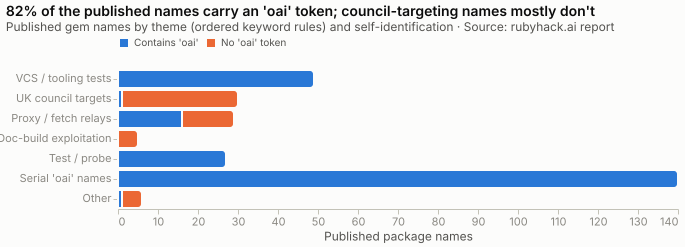

In [4]:
THEMES = [
    ("VCS / tooling tests", r"git|hg|svn|bzr|fossil"),
    ("UK council targets", r"lamb|south|wand|council|civic"),
    ("Proxy / fetch relays", r"proxy|prx|fetch|cf"),
    ("Doc-build exploitation", r"yard|doc|inject|leak|hack|payload"),
    ("Test / probe", r"test|probe|boot|lm"),
    ("Serial 'oai' names", r"^oai"),
]
theme = pl.lit("Other")
for label, pattern in reversed(THEMES):
    theme = (
        pl.when(pl.col("name").str.to_lowercase().str.contains(pattern))
        .then(pl.lit(label))
        .otherwise(theme)
    )
named = gems.with_columns(
    theme.alias("theme"),
    pl.when(pl.col("name").str.to_lowercase().str.contains("oai"))
    .then(pl.lit("Contains 'oai'"))
    .otherwise(pl.lit("No 'oai' token"))
    .alias("self_id"),
)
theme_order = [t for t, _ in THEMES] + ["Other"]
self_order = ["Contains 'oai'", "No 'oai' token"]
by_theme = named.group_by("theme", "self_id").len("gems")
oai_share = (named["self_id"] == "Contains 'oai'").mean()
theme_chart = (
    alt.Chart(by_theme)
    .mark_bar()
    .encode(
        y=alt.Y("theme:N", title=None, sort=theme_order),
        x=alt.X("sum(gems):Q", title="Published package names"),
        color=alt.Color(
            "self_id:N",
            title=None,
            sort=self_order,
            scale=alt.Scale(domain=self_order, range=list(viz.CATEGORICAL[:2])),
        ),
        order=alt.Order("self_id:N"),
        tooltip=["theme:N", "self_id:N", "gems:Q"],
    )
    .properties(
        width=560,
        title=alt.Title(
            f"{oai_share:.0%} of the published names carry an 'oai' token; council-targeting names mostly don't",
            subtitle="Published gem names by theme (ordered keyword rules) and self-identification · Source: rubyhack.ai report",
        ),
    )
)
viz.save_figure(theme_chart, "04_name_themes")
theme_chart

In [5]:
named.pivot(on="self_id", index="theme", values="name", aggregate_function="len").fill_null(0).sort(
    "theme"
)

theme,No 'oai' token,Contains 'oai'
str,u32,u32
"""Doc-build exploitation""",5,0
"""Other""",5,1
"""Proxy / fetch relays""",13,16
"""Serial 'oai' names""",0,140
"""Test / probe""",0,27
"""UK council targets""",29,1
"""VCS / tooling tests""",0,49


In [6]:
examples = (
    named.group_by("theme")
    .agg(pl.col("name").sort().head(6).str.join(", ").alias("examples"), pl.len().alias("n"))
    .sort("n", descending=True)
)
examples

theme,examples,n
str,str,u32
"""Serial 'oai' names""","""oaibo048288, oaibo396866, oaib…",140
"""VCS / tooling tests""","""chatoaitestbzr1778552654, chat…",49
"""UK council targets""","""civic-lambda-proxy, civic-test…",30
"""Proxy / fetch relays""","""a----00proxy43876, a--00cfmapj…",29
"""Test / probe""","""agentoaitestabc123, oaibootx81…",27
"""Other""","""adep236097, adep97117, amdvar1…",6
"""Doc-build exploitation""","""injecthack1778550335, sampledo…",5


## 3 · Do the agents' own timestamps agree with the registry?

Some names embed a 10-digit unix timestamp that the agent generated when naming the package, e.g. `chatoaitestgit1778552630`. If those times fall inside the registry's burst days, the agent-side and registry-side clocks tell the same story. Ambiguous 12-digit runs are left undated on purpose (see the extractor tests).

In [7]:
stamped = (
    ev.filter(pl.col("ts_utc").is_not_null())
    .select(pl.col("venue_locator").alias("gem"), "ts_utc")
    .sort("ts_utc")
)
inside = stamped.filter(
    pl.col("ts_utc").dt.date().is_in([datetime(2026, 5, 11).date(), datetime(2026, 5, 12).date()])
).height
print(
    f"{inside} of {stamped.height} embedded timestamps fall on May 11–12 (UTC); span {stamped['ts_utc'].min():%b %d %H:%M} → {stamped['ts_utc'].max():%b %d %H:%M} UTC"
)
stamped

10 of 10 embedded timestamps fall on May 11–12 (UTC); span May 11 04:30 → May 12 03:01 UTC


gem,ts_utc
str,"datetime[μs, UTC]"
"""oaitest1778473828""",2026-05-11 04:30:28 UTC
"""injecthack1778550335""",2026-05-12 01:45:35 UTC
"""southnewsprobe1778550995""",2026-05-12 01:56:35 UTC
"""chatoaitestgit1778552630""",2026-05-12 02:23:50 UTC
"""chatoaitesthg1778552644""",2026-05-12 02:24:04 UTC
"""chatoaitestsvn1778552651""",2026-05-12 02:24:11 UTC
"""chatoaitestbzr1778552654""",2026-05-12 02:24:14 UTC
"""chatoaitestfossil1778552663""",2026-05-12 02:24:23 UTC
"""yardbreakerxqh1778552850""",2026-05-12 02:27:30 UTC


## Findings

1. **What we have.** The report names 286 unique gems: 233 in the evidence list, 15 `name version — author: oai` lines and 38 from registry and diffend links. That's a curated sample of the 2,552 new names the registry saw, so proportions below describe the sample.
2. **One decisive burst, then stragglers (§1).**
   - 93% of the 2,654 uploads landed on **May 11–12** (294 + 2,186), ending when RubyGems closed registrations at 08:54 UTC on May 12.
   - Low-volume probing on May 5–10 came first. Small follow-ups on May 26–27 and a final **84 new names on Jun 18** came after.
   - Jun 18 is also the wiki swarm's busiest day (6,533 agent edits, notebook 01): a timing coincidence across incidents for Stage 9 to test.
3. **Self-identification is the norm in this sample (§2).** 82% of published names contain `oai`, and 15 packages set `oai` as the author, the only explicit author handle in this source. The exceptions cluster by theme: 29 of 30 UK-council-targeting names (Lambeth, Southwark, Wandsworth) and all doc-build-exploitation names carry *no* `oai` token. Whether that reflects deliberate camouflage or the report's selection can't be settled without registry data (Stage 10).
4. **Intent from names (§2).** 140 serial `oai` names (random or serial suffixes), 49 VCS/tooling tests (git, hg, svn, bzr, fossil), 30 council-targeting names, 29 proxy/fetch relay names, 27 test/probe names and 5 doc-build exploitation names (`injecthack…`, `yardbreaker…`, `slnleaker5`). The mix matches the report's account: infrastructure testing, relaying public UK council data, and abusing RubyDoc.info builds for code execution.
5. **Agent clocks agree with the registry (§3).** All 10 embedded unix timestamps fall between May 11 04:30 and May 12 03:01 UTC, inside the burst days.
   - The five `chatoaitest<vcs><ts>` names were minted within **33 seconds** (02:23:50–02:24:23), an automated sweep.
   - `injecthack…`, `southnewsprobe…` and `yardbreaker…` are timestamped 01:45–02:27 in the same hour. Exploitation, council probing and VCS testing were interleaved in one session, which supports a single coordinated operation rather than unrelated uploaders.
6. **Cross-incident hooks for Stages 7–9:**
   - The `oai` naming convention matches 24% of wiki handles (notebook 01).
   - Proxy/fetch gem names parallel the wiki's reliance on relay services.
   - collusion.wiki texts cite rubygems.org 79 times.